# The count behind 40 percent

**Week 1, Thursday. Notebook 3 of 3, round 3.** By the end of this notebook you can count what a rate
stands on, run a chance reference for a small count, and say "not yet" with the number that would
turn it into a yes.

> **The client asks.** "Student is up 40 percent; should I move budget there?"
>
> Meera Raghavan, CEO, Kalpa Retail

> **Kavya's review, before you start.** "Write the count next to the rate, every time. If chance makes
> that rate on that count, the line to Meera is 'not yet'."

Notebooks 1 and 2 found the Retail-Plus fall real and small against the company. Meera's second
question is about a rise, the biggest on the page, and it needs a different check first.

**Setup.** The same file and helpers as notebooks 1 and 2.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, one number per member."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def mean(values):
    return sum(values) / len(values)


def shuffle_gaps(q1, q2, times, seed):
    """Deal the pooled values to two piles at random, many times, and keep each gap."""
    random.seed(seed)
    pool = q1 + q2
    gaps = []
    for _ in range(times):
        random.shuffle(pool)
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def histogram(gaps, step):
    """Count the gaps in bins of one width, for a columns chart of thousands of shuffles."""
    lo = int(min(gaps) // step) * step
    edges = list(range(lo, int(max(gaps)) + step, step))
    counts = [sum(1 for g in gaps if a <= g < a + step) for a in edges]
    labels = [f"{a + step // 2:,}" for a in edges]
    return labels, counts

SEGMENTS = ["Retail-Core", "Retail-Plus", "Business", "Student"]
print("helpers ready for", len(SEGMENTS), "segments")

helpers ready for 4 segments


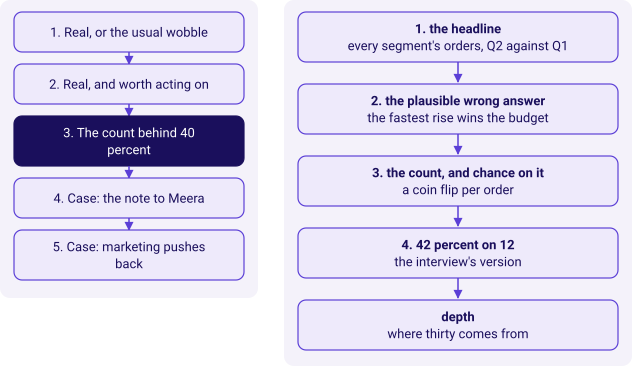

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the usual wobble', 'Real, and worth acting on', 'The count behind 40 percent', 'Case: the note to Meera', 'Case: marketing pushes back'], lit=2, show=False),
    kit.vflow(["1. the headline\nevery segment's orders, Q2 against Q1",
               "2. the plausible wrong answer\nthe fastest rise wins the budget",
               "3. the count, and chance on it\na coin flip per order",
               "4. 42 percent on 12\nthe interview's version",
               "depth\nwhere thirty comes from"], show=False),
)

## 1. The headline: every segment's orders, Q2 against Q1

Meera's 40 percent is about orders. Put every segment on the same footing: Q2 orders for every 100
orders in Q1.

**Predict before you run.** Which segment shows the biggest rise? a) Business, since it carries the
revenue; b) Retail-Core; c) Student; d) none rose.

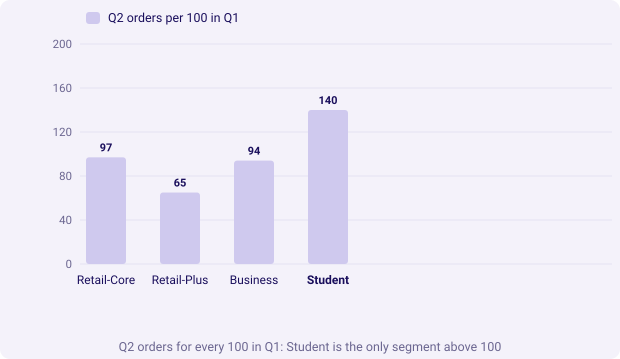

Retail-Core  -3 percent
Retail-Plus  -35 percent
Business     -6 percent
Student      +40 percent


In [3]:
def orders_in(segment, quarter):
    return sum(1 for o in ORDERS if o["segment"] == segment and o["quarter"] == quarter)


index = {s: round(100 * orders_in(s, "Q2") / orders_in(s, "Q1")) for s in SEGMENTS}
kit.columns(SEGMENTS, [("Q2 orders per 100 in Q1", [index[s] for s in SEGMENTS])], lit=[3], width=620,
            title="Q2 orders for every 100 in Q1: Student is the only segment above 100")
for s in SEGMENTS:
    print(f"{s:12s} {index[s] - 100:+d} percent")

**What happened.** The answer is c. Student is the only segment whose orders rose, by 40 percent,
while Retail-Plus fell 35 and the other two slipped a few points. Read as a leaderboard, Student wins.

In [4]:
kit.check("Student's orders rose 40 percent", index["Student"] == 140, f"{index['Student']}")
kit.check("Student is the only segment above 100", [s for s in SEGMENTS if index[s] > 100] == ["Student"])

## 2. The plausible wrong answer

**The plausible wrong answer.** The draft reads the leaderboard as a plan:

In [5]:
fastest = max(SEGMENTS, key=lambda s: index[s])
draft = f"{fastest} is up {index[fastest] - 100} percent, the fastest on the page: move acquisition budget to {fastest}."
print(draft)

Student is up 40 percent, the fastest on the page: move acquisition budget to Student.


**Why it is wrong.** The rate is correct arithmetic and it travels without its count. A rise of 40
percent on four hundred orders and on a handful of orders are different facts: on a handful, one or
two orders landing in one quarter rather than the other makes the whole rise. The check is to count
what the rate stands on before repeating it.

**Your turn.** Type these lines into the empty cell below and run them. Then write, in one sentence,
how many orders and how many customers stand behind Meera's 40 percent:

```python
student = [o for o in ORDERS if o["segment"] == "Student"]
print(len(student), "Student orders across both quarters")
print({q: sum(1 for o in student if o["quarter"] == q) for q in ("Q1", "Q2")})
print(len({o["customer_id"] for o in student}), "distinct Student customers")
```

The mechanism, on **invented** segments, before the chance reference: how many points one extra order
moves a rate, at four sizes.

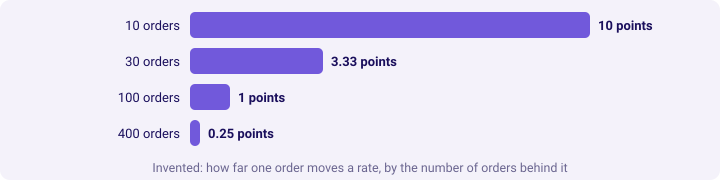

In [6]:
sizes = [10, 30, 100, 400]
kit.bars([(f"{n} orders", round(100 / n, 2)) for n in sizes], fmt=lambda v: f"{v:g} points",
         title="Invented: how far one order moves a rate, by the number of orders behind it")
kit.check("on ten orders, one order is ten points", 100 / sizes[0] == 10)

## 3. The count, and chance on it: a coin flip per order

Round one's shuffle mixed labels between two quarters. For a count, the chance reference is simpler:
if Student's ordering had not changed, each Student order was as likely to land in Q1 as in Q2. Flip
a coin per order, 5,000 times, and count how often chance alone makes a rise of 40 percent or more.

**Predict before you run.** For Student's own orders, what share of coin-flip worlds show a rise of
40 percent or more? a) under 1 percent; b) about 5 percent; c) about 40 percent; d) all of them.

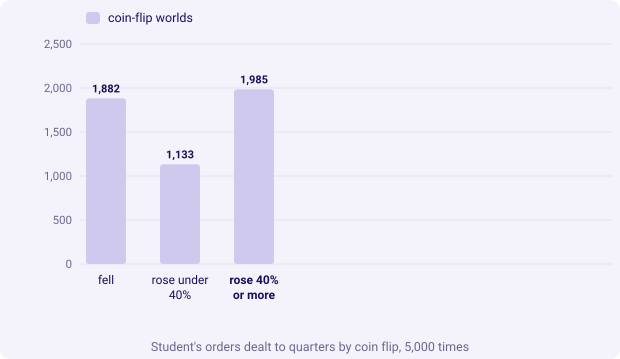

share of chance-only worlds with a rise of 40 percent or more: 0.397


In [7]:
def flip_rises(n_orders, times, seed):
    """Deal each of n orders to Q1 or Q2 by a fair coin, many times, and keep each rise."""
    random.seed(seed)
    rises = []
    for _ in range(times):
        q2 = sum(1 for _ in range(n_orders) if random.random() < 0.5)
        q1 = n_orders - q2
        rises.append(float("inf") if q1 == 0 else q2 / q1 - 1)
    return rises


def bucket(rises):
    """Three plain buckets, so the chart says what the decision needs and nothing else."""
    return [sum(1 for r in rises if r < 0), sum(1 for r in rises if 0 <= r < 0.4 - 1e-9),
            sum(1 for r in rises if r >= 0.4 - 1e-9)]


student_n = sum(1 for o in ORDERS if o["segment"] == "Student")
student_rises = flip_rises(student_n, 5000, seed=2026)
student_share = sum(1 for r in student_rises if r >= 0.4 - 1e-9) / len(student_rises)
kit.columns(["fell", "rose under 40%", "rose 40% or more"], [("coin-flip worlds", bucket(student_rises))],
            lit=[2], width=620, title="Student's orders dealt to quarters by coin flip, 5,000 times")
print(f"share of chance-only worlds with a rise of 40 percent or more: {student_share:.3f}")

**What happened.** The answer is c. About four in ten coin-flip worlds make a rise of 40 percent or
more from Student's orders alone. Chance makes Meera's headline almost as often as not.

Now the same 40 percent on bigger counts: a segment with Retail-Core's 73 orders, and an **invented**
segment of 400.

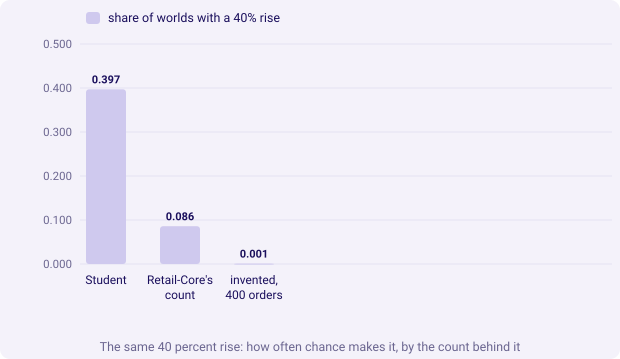

Behind the rate,Chance makes a 40% rise
Student,39.7%
Retail-Core's count,8.6%
"invented, 400 orders",0.1%


In [8]:
core_n = sum(1 for o in ORDERS if o["segment"] == "Retail-Core")
compare = {"Student": student_share}
for label, n in [("Retail-Core's count", core_n), ("invented, 400 orders", 400)]:
    rises = flip_rises(n, 5000, seed=2026)
    compare[label] = sum(1 for r in rises if r >= 0.4 - 1e-9) / len(rises)
kit.columns(list(compare), [("share of worlds with a 40% rise", [round(v, 3) for v in compare.values()])],
            fmt=lambda v: f"{v:.3f}", width=620, title="The same 40 percent rise: how often chance makes it, by the count behind it")
kit.table(["Behind the rate", "Chance makes a 40% rise"], [(k, f"{v:.1%}") for k, v in compare.items()])

In [9]:
kit.check("chance makes Student's rise in more than a third of worlds", student_share > 0.33, f"{student_share:.3f}")
core_share = compare["Retail-Core's count"]
kit.check("on Retail-Core's count the same rise is rare", core_share < 0.10, f"{core_share:.3f}")
kit.check("on 400 orders chance almost never makes it", compare["invented, 400 orders"] < 0.002)

**The fix.** The rate, its count, and whether chance makes it, with the decision that follows:

Student orders rose 40 percent, on a count so small that chance alone makes a rise that size in 40% of coin-flip worlds. Not yet: we watch Student until it carries at least thirty orders a quarter before any budget moves.


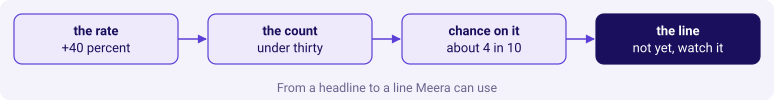

In [10]:
fixed = (f"Student orders rose 40 percent, on a count so small that chance alone makes a rise that size "
         f"in {student_share:.0%} of coin-flip worlds. Not yet: we watch Student until it carries at least "
         f"thirty orders a quarter before any budget moves.")
print(fixed)
kit.flow(["the rate\n+40 percent", "the count\nunder thirty", "chance on it\nabout 4 in 10",
          "the line\nnot yet, watch it"], lit=3, title="From a headline to a line Meera can use")
kit.check("the fixed line carries the chance share and the threshold", "thirty" in fixed and f"{student_share:.0%}" in fixed)

What changed: the decision. The draft moved budget; the fix moves nothing and names the count that
would reopen the question. The rule of thumb is the row's: under thirty observations, a rate is a
lead, never a finding.

## 4. 42 percent on 12 users, or 31 percent on 1,200?

The interview's version of Student. Suppose the true rate for everyone were 31 percent. How often would
a group of only 12 users show 42 percent or more, by chance alone? This is invented, with the
interview's numbers.

**Predict before you run.** a) almost never; b) about 1 time in 20; c) about 1 time in 3; d) always.

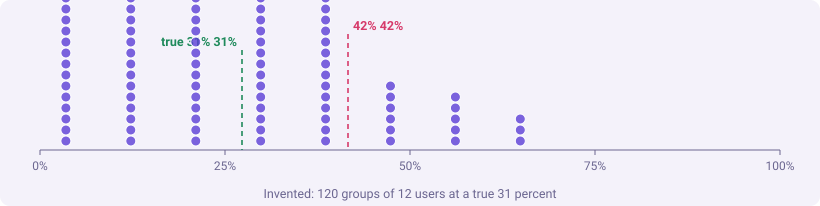

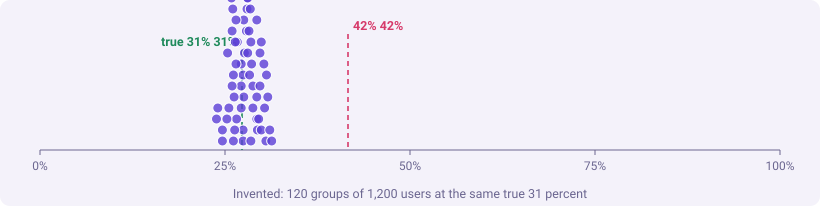

groups of 12 at 42% or more: 30.9%; groups of 1,200: 27.7% to 34.8%


In [11]:
random.seed(2026)
small_rates = [sum(1 for _ in range(12) if random.random() < 0.31) / 12 for _ in range(5000)]
large_rates = [sum(1 for _ in range(1200) if random.random() < 0.31) / 1200 for _ in range(300)]
small_share = sum(1 for r in small_rates if r >= 5 / 12 - 1e-9) / len(small_rates)
kit.strip(small_rates[:120], markers=[("42%", 5 / 12, "bad"), ("true 31%", 0.31, "good")], lo=0, hi=1,
          fmt=lambda v: f"{v:.0%}", title="Invented: 120 groups of 12 users at a true 31 percent")
kit.strip(large_rates[:120], markers=[("42%", 5 / 12, "bad"), ("true 31%", 0.31, "good")], lo=0, hi=1,
          fmt=lambda v: f"{v:.0%}", title="Invented: 120 groups of 1,200 users at the same true 31 percent")
print(f"groups of 12 at 42% or more: {small_share:.1%}; groups of 1,200: {min(large_rates):.1%} to {max(large_rates):.1%}")

**What happened.** The answer is c. A true 31 percent shows up as 42 percent or more in about 31
percent of groups of twelve, while groups of 1,200 all land between about 27 and 35 percent. One user
out of twelve is 8.3 points; one out of 1,200 is under a tenth of a point.

In [12]:
kit.check("a true 31 percent reads 42 or more on 12 users about a third of the time", 0.25 < small_share < 0.37,
          f"{small_share:.3f}")
kit.check("on 1,200 users it never reaches 42 percent", max(large_rates) < 5 / 12, f"{max(large_rates):.3f}")

> **Kavya's review.** "Student's rise is real arithmetic on too few orders to act on. Count them, say
> how often chance makes the rise, and give Meera the number that would reopen it. That is a complete
> answer, and it costs nothing to be right later."

### In the interview

**[F] 42 percent on 12 users against 31 percent on 1,200; which do you trust?** "The 31 percent, as
the working estimate. On 12 users one person moves the rate by more than 8 points, so 42 percent is
well inside what chance produces around a true rate near 31. I would keep the 42 as a lead: find out
what is different about that group and measure it on more users before acting." The interviewer
listens for the one-person swing, the word estimate, and a next step that is cheaper than acting.

**[F] Revenue rose after a discount; did the campaign work, and what would you need to know?** Kept
for the afternoon, where it is the case; the full answer is in the escalated case's solution
notebook.

### Depth: where thirty comes from

Thirty is a habit, never a law: it is roughly where a count stops swinging wildly from one extra
observation. The curve below is the coin-flip chance of a 40 percent rise at growing counts, the same
simulation as section 3.

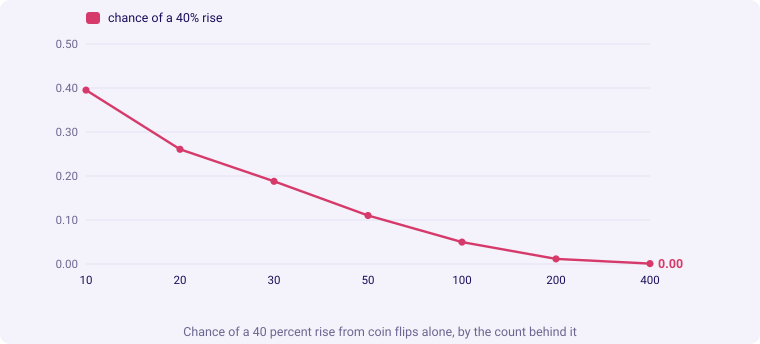

In [13]:
counts = [10, 20, 30, 50, 100, 200, 400]
curve = []
for n in counts:
    rises = flip_rises(n, 3000, seed=2026)
    curve.append(sum(1 for r in rises if r >= 0.4 - 1e-9) / len(rises))
kit.line([str(n) for n in counts], [("chance of a 40% rise", curve, "bad")], fmt=lambda v: f"{v:.2f}",
         title="Chance of a 40 percent rise from coin flips alone, by the count behind it")
kit.check("the chance falls below one in five by thirty orders", curve[2] < 0.2, f"{curve[2]:.3f}")

In [14]:
kit.check_summary()
print("Next: the afternoon's escalated case, with the discount question the morning left open.")

Next: the afternoon's escalated case, with the discount question the morning left open.
